# Atividade de vendas no Brasil

## Entregável 1 NumPy

In [34]:
import pandas as pd
import numpy as np

df = pd.read_csv('vendas_brasil_1.csv')
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


### A. Criando arrays

In [35]:
preco = df['preco_unitario'].to_numpy()
custo = df['custo_unitario'].to_numpy()
quantidade = df['quantidade'].to_numpy()
desconto = df['desconto_pct'].to_numpy()
receita = df['receita_total'].to_numpy()

resumo_arrays = pd.DataFrame({
    "preco": preco,
    "custo": custo,
    "quantidade": quantidade,
    "desconto": desconto,
    "receita": receita
}).head()

resumo_arrays

,preco,custo,quantidade,desconto,receita
0,739.39,561.75,10,5.2,6933.48
1,187.48,135.15,5,0.6,930.28
2,76.11,61.40,14,0.7,1058.50
3,145.86,88.53,11,0.6,1592.43
4,133.92,107.25,1,19.5,107.64


### B. Cálculos com operações vetorizadas

In [36]:
valor_bruto = preco * quantidade
valor_desconto = valor_bruto * (desconto / 100)
custo_total = custo * quantidade
lucro_estimado = (valor_bruto - valor_desconto) - custo_total

resumo_calculos = pd.DataFrame({
    "valor_bruto": valor_bruto,
    "valor_desconto": valor_desconto,
    "custo_total": custo_total,
    "lucro_estimado": lucro_estimado
}).head()

resumo_calculos

,valor_bruto,valor_desconto,custo_total,lucro_estimado
0,7393.90,384.48280,5617.50,1391.91720
1,937.40,5.62440,675.75,256.02560
2,1065.54,7.45878,859.60,198.48122
3,1604.46,9.62676,973.83,621.00324
4,133.92,26.11440,107.25,0.55560


### C. Máscaras booleanas

In [42]:
receita_media = np.nanmean(receita)

mask_acima_media = receita > receita_media
mask_prejuizo = lucro_estimado < 0
mask_desconto_alto = desconto > 20

print(f"Receita media: R$ {receita_media:,.2f}\n")
print(f"Vendas com receita acima da media: {mask_acima_media.sum()}")
print(f"Vendas com prejuizo:               {mask_prejuizo.sum()}")
print(f"Vendas com desconto alto (>20%):   {mask_desconto_alto.sum()}")


Receita media: R$ 1,891.69

Vendas com receita acima da media: 9236
Vendas com prejuizo:               2857
Vendas com desconto alto (>20%):   7037


### D. Agregações

In [40]:
print("Medidas gerais calculadas com NumPy:\n")
print(f"Receita media:         R$ {np.nanmean(receita):,.2f}")
print(f"Maior receita:         R$ {np.nanmax(receita):,.2f}")
print(f"Menor receita:         R$ {np.nanmin(receita):,.2f}")
print(f"Lucro estimado medio:  R$ {np.nanmean(lucro_estimado):,.2f}")
print(f"Qtd. de vendas c/ prejuizo: {mask_prejuizo.sum()} ({100 * mask_prejuizo.mean():.1f}% do total)")

Medidas gerais calculadas com NumPy:

Receita media:         R$ 1,891.69
Maior receita:         R$ 58,430.28
Menor receita:         R$ 3.70
Lucro estimado medio:  R$ 342.03
Qtd. de vendas c/ prejuizo: 2857 (7.6% do total)


### Conclusão do Entregável 1

Com base nos cálculos vetorizados e nas agregações feitas com NumPy, podemos destacar os seguintes cenários sobre a operação:

Operação Lucrativa: No geral, o negócio se mantém saudável, apresentando um lucro estimado médio de R$ 342,03 por pedido.

Prejuízos: Aproximadamente 7,6% das vendas (2.857 casos) fecharam no negativo.

Impacto das Promoções: Houveram 7037 vendas com descontos superiores à 20%.
Esse volume alto de descontos pode ser um dos motivos que está alterando a margem de lucro.

Amplitude de Ticket: Enquanto a receita média é de R$ 1.891,69, temos vendas que vão de R$ 3,70 até R$ 58.430,28.

## Entregável 2 Pandas

### A. Primeiro olhar no dataset

In [14]:
df.head()
df.info()
df.describe()
df.shape
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

,0
data_venda,0
mes,0
cidade,0
canal_venda,50
categoria,0
produto,0
vendedor,40
fidelidade_cliente,0
preco_unitario,0
custo_unitario,0


**Respostas da Exploração Inicial:**

1. **Quantas linhas e colunas existem?** O dataset possui 37.617 linhas e 21 colunas, conforme observado no comando shape.
2. **Existem dados faltantes?** Sim. Existem valores faltantes nas colunas canal_venda, vendedor, margem_pct, frete, avaliacao_cliente e prazo_entrega_dias.
3. **Quais colunas parecem numéricas?** As colunas mes, preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente e prazo_entrega_dias.
4. **Quais colunas parecem categóricas?** As colunas cidade, canal_venda, categoria, produto, vendedor, e fidelidade_cliente, além das variáveis booleanas como devolucao e entrega_no_prazo.

### B. Limpeza e tratamento

In [43]:
df['data_venda'] = pd.to_datetime(df['data_venda'], format='mixed', dayfirst=True)
df['cidade'] = df['cidade'].str.title()
df['avaliacao_cliente'] = df['avaliacao_cliente'].fillna(df['avaliacao_cliente'].median())
df['frete'] = df['frete'].fillna(0)

df[['data_venda', 'cidade', 'avaliacao_cliente', 'frete']].head()

,data_venda,cidade,avaliacao_cliente,frete
0,2022-04-13,Rio De Janeiro,4.92,8.68
1,2023-03-12,Manaus,4.98,0.00
2,2022-09-28,Goiânia,3.47,7.98
3,2022-04-17,Fortaleza,4.50,20.49
4,2022-03-13,Belo Horizonte,3.49,22.89


**Decisões tomadas na limpeza:**

* A coluna de data foi convertida para datetime para permitir cálculos com tempo.
* A coluna cidade foi padronizada com a primeira letra maiúscula para evitar duplicidade.
* Para os dados faltantes em avaliacao_cliente, utilizou-se a mediana, porque ela é menos sensível a outliers.
* Na coluna categórica fidelidade_cliente, os valores nulos foram preenchidos como "Não Informado".

### C. Criação de novas colunas

In [44]:
df['ano_venda'] = df['data_venda'].dt.year
df['mes_venda'] = df['data_venda'].dt.month
df['lucro_total'] = df['receita_total'] - ((df['custo_unitario'] * df['quantidade']) + df['frete'])
df['faixa_receita'] = df['receita_total'].apply(lambda x: 'Alta' if x > 2000 else ('Média' if x > 500 else 'Baixa'))

df[['ano_venda', 'mes_venda', 'lucro_total', 'faixa_receita']].head()

,ano_venda,mes_venda,lucro_total,faixa_receita
0,2022,4,1307.30,Alta
1,2023,3,254.53,Média
2,2022,9,190.92,Média
3,2022,4,598.11,Média
4,2022,3,-22.50,Baixa


### D. Filtros

In [46]:
vendas_alta_receita = df[df['receita_total'] > 1000]
vendas_alta_receita.head()
vendas_devolvidas = df[df['devolucao'] == 'Sim']
vendas_devolvidas.head()
vendas_eletronicos = df[df['categoria'] == 'Eletrônicos']
vendas_eletronicos.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,mes_venda,lucro_total,faixa_receita
0,2022-04-13,4,Rio De Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,4.92,5.0,False,True,False,False,2022,4,1307.30,Alta
15,2022-04-10,4,Salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,3.52,12.0,False,False,False,True,2022,4,1997.43,Alta
17,2022-05-11,5,Belo Horizonte,App Mobile,Eletrônicos,Smartwatch,Elisa Costa,Prata,732.37,536.37,...,2.94,4.0,False,True,False,False,2022,5,47.65,Alta
20,2022-12-10,12,Recife,Site Web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,4.47,13.0,False,True,True,False,2022,12,5659.01,Alta
21,2023-05-07,5,São Paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,1.05,18.0,True,True,False,True,2023,5,1552.92,Alta


**Análise dos filtros:**
Foi identificado que uma parcela considerável das vendas de alta receita está concentrada na categoria de Eletrônicos. Além disso, as devoluções parecem não seguir um padrão específico de cidade, o que pode sugerir problemas de produto.

### E. Agrupamentos com groupby

In [47]:
receita_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)
display(pd.DataFrame(receita_categoria))

vendas_canal = df.groupby('canal_venda')['quantidade'].sum().sort_values(ascending=False)
display(pd.DataFrame(vendas_canal))

,receita_total
categoria,
Eletrônicos,45017479.88
Esportes,11567480.75
Vestuário,6780473.93
Livros,4462597.93
Alimentação,3331601.51


,quantidade
canal_venda,
Site Web,84503
App Mobile,83188
Loja Física,56318
Marketplace,41707
Televendas,13726
app mobile,240
SiteWeb,231
APP Mobile,221
Site web,203


### F. Merge (Tabela Auxiliar)

In [48]:
tabela_regioes = pd.DataFrame({
    'cidade': ['São Paulo', 'Rio De Janeiro', 'Belo Horizonte', 'Curitiba', 'Salvador', 'Goiânia', 'Fortaleza', 'Manaus'],
    'regiao': ['Sudeste', 'Sudeste', 'Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Nordeste', 'Norte']
})

df_merge = df.merge(tabela_regioes, on='cidade', how='left')

receita_por_regiao = df_merge.groupby('regiao')['receita_total'].sum().sort_values(ascending=False)
pd.DataFrame(receita_por_regiao)

,receita_total
regiao,
Sudeste,20499558.81
Nordeste,14112777.66
Norte,7435641.08
Centro-Oeste,7137063.48
Sul,6932809.19


### Conclusão do Entregável 2

O dataset estava sujo e precisava de tratamento. O tratamento aplicado foi padrão, sendo usado na etapa de transformação de diversos processos ETL.

A categoria de eletrônicos é lider em receita total e em lucro, ao mesmo tempo que as categorias de ticket baixo acumulam uma receita bastante inferior.

## Entregável 3 Seaborn

Nesta última etapa, o objetivo é criar visualizações dos dados utilizando a biblioteca Seaborn para entender melhor a distribuição, as relações e o comportamento geral das vendas.



In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

### A. Gráfico de Barras: Receita por Categoria

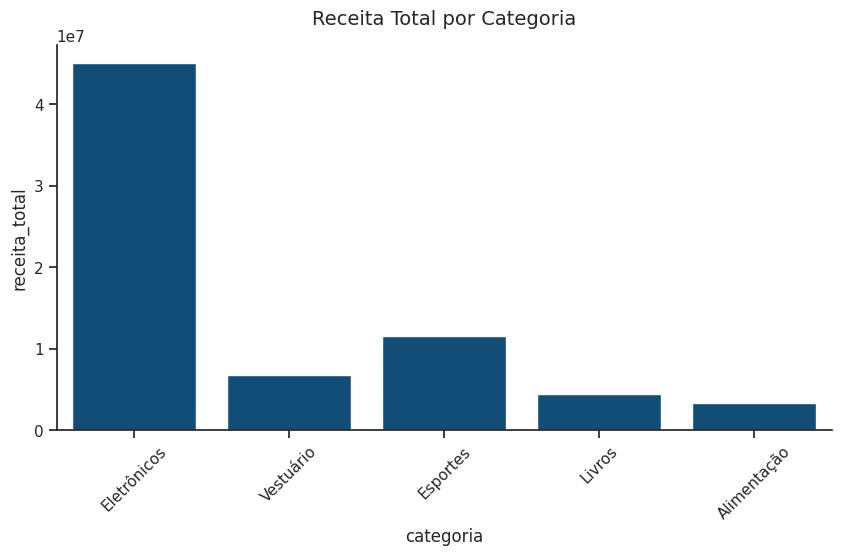

In [50]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='categoria', y='receita_total', estimator=sum, errorbar=None, color='#005088')
plt.title('Receita Total por Categoria', fontsize=14, pad=15)
plt.xticks(rotation=45)
sns.despine()
plt.show()

### B. Gráfico de linha


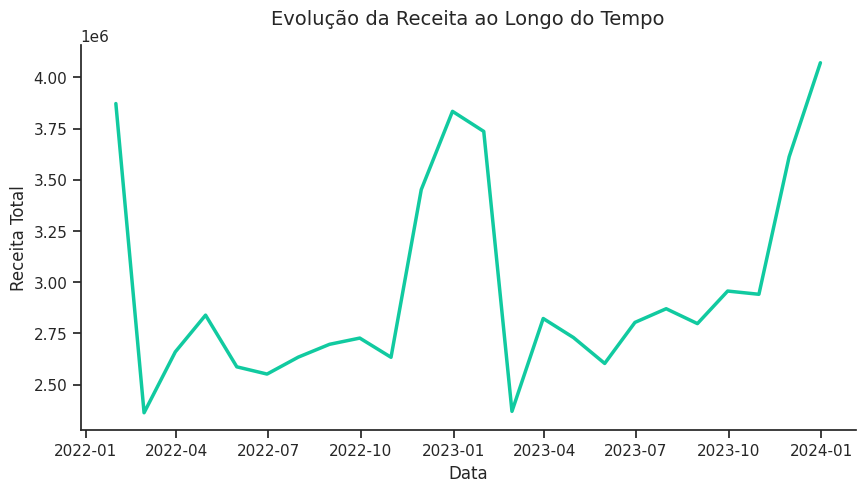

In [51]:
df_mes = df.resample('ME', on='data_venda')['receita_total'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_mes, x='data_venda', y='receita_total', linewidth=2.5, color='#11caa0')
plt.title('Evolução da Receita ao Longo do Tempo', fontsize=14, pad=15)
plt.xlabel('Data')
plt.ylabel('Receita Total')
sns.despine()
plt.show()

### C. Gráfico de dispersão

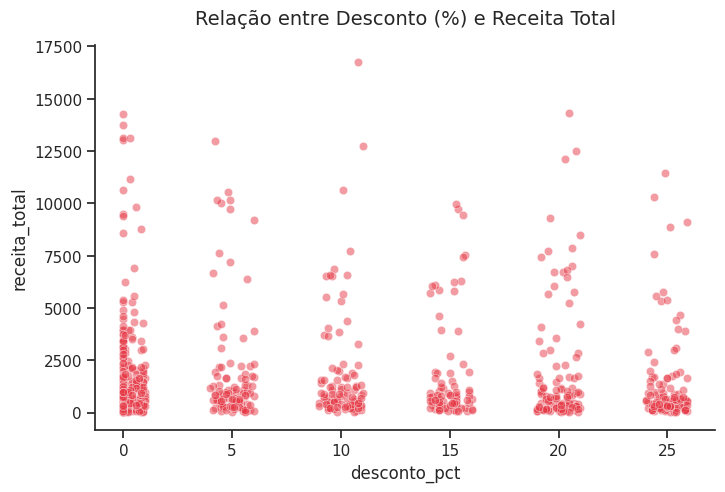

In [52]:
df_amostra = df.sample(800, random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_amostra, x='desconto_pct', y='receita_total', alpha=0.5, color='#e63946')
plt.title('Relação entre Desconto (%) e Receita Total', fontsize=14, pad=15)
sns.despine()
plt.show()

### D. Mapa de calor


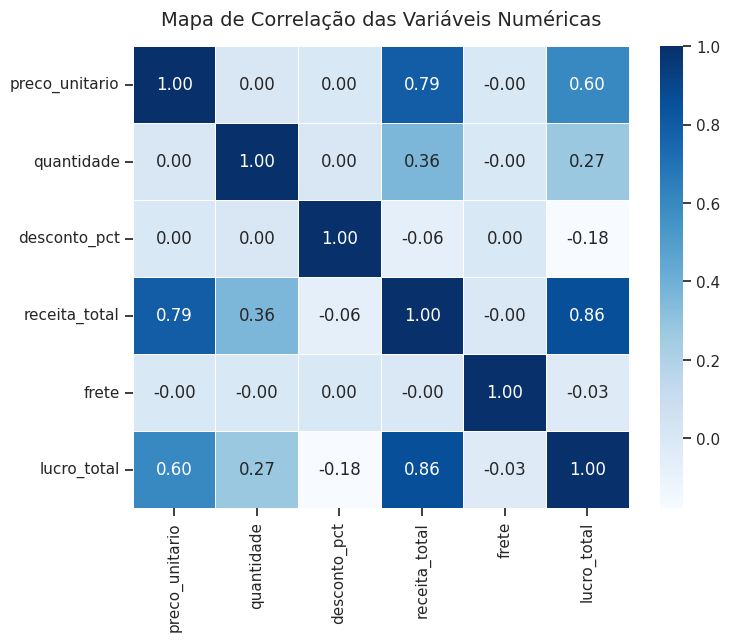

In [53]:
colunas_num = ['preco_unitario', 'quantidade', 'desconto_pct', 'receita_total', 'frete', 'lucro_total']
matriz_corr = df[colunas_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='Blues', fmt=".2f", linewidths=.5)
plt.title('Mapa de Correlação das Variáveis Numéricas', fontsize=14, pad=15)
plt.show()

###Conclusão Final:

Com base nos gráficos gerados pelo Seaborn, podemos estabelecer os seguintes padrões sobre a operação da empresa:

Dependência de Categoria: O gráfico de barras evidencia  que a categoria de Eletrônicos é o principal motor financeiro do negócio.

Sazonalidade Agressiva: O gráfico de linha mostra mudança dinâmica na receita, culminando em um pico de crescimento  no final do período (final de 2023 e início de 2024). Isso sugere uma forte dependência de datas sazonais de fim de ano, como Black Friday e Natal.

Política de DescontosIneficiente: Pelo gráfico de dispersão, notamos que os descontos são dados em faixas exatas (0%, 5%, 10%, 15%, 20%, 25%). Além disso, conceder os maiores descontos (20% e 25%) não gerou pedidos de maior valor.

Motores do Lucro: O mapa de demonstra os problemas e as soluções. O percentual de desconto tem correlação negativa tanto com a receita (-0.06) quanto com o lucro total (-0.18), ou seja, está apenas corroendo a margem. A receita total, por sua vez, é puxada fortemente pelo preço unitário (0.79) e não pela quantidade de itens (0.36).
